# 图表反演

In [1]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

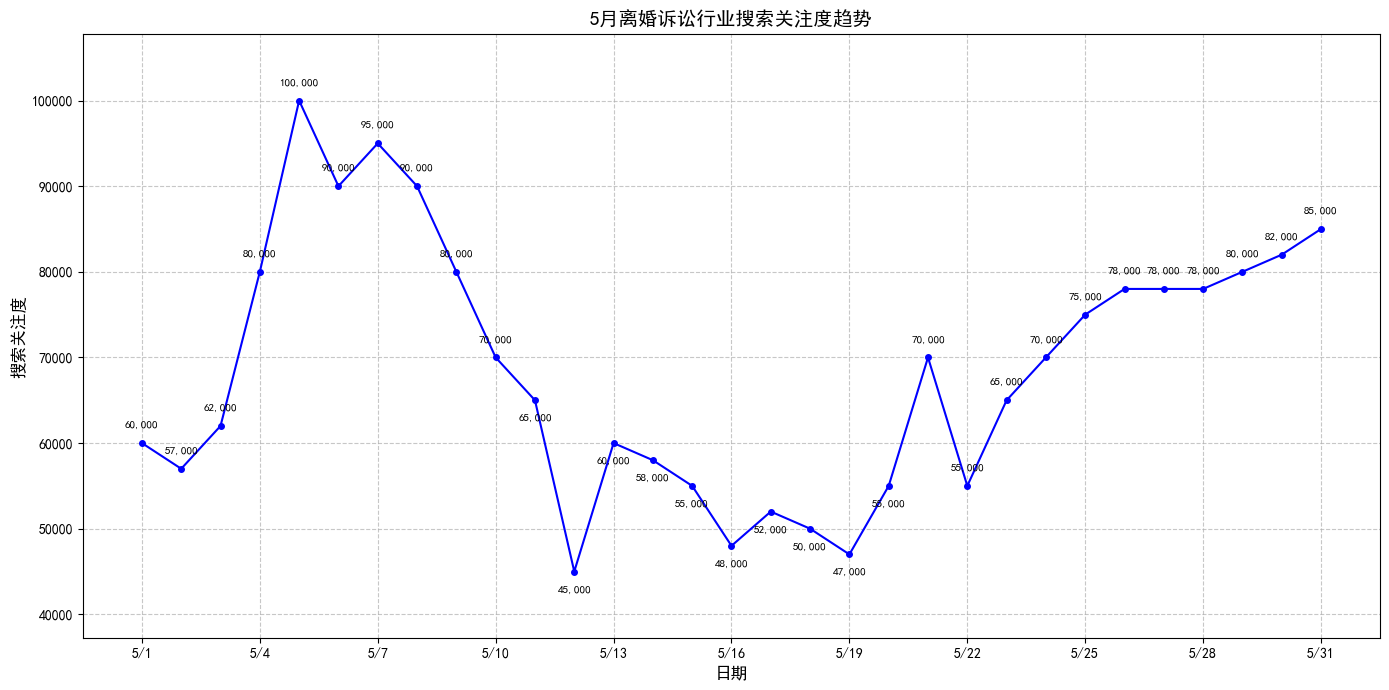

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 日期数据，这里用字符串表示，后续处理显示
dates = [f"5/{i}" for i in range(1, 32)]
# 对应每日搜索关注度近似数据（从图中读取，仅为示例，需按实际调整）
values = [60000, 57000, 62000, 80000, 100000, 90000, 95000, 90000, 80000, 70000, 
          65000, 45000, 60000, 58000, 55000, 48000, 52000, 50000, 47000, 55000, 
          70000, 55000, 65000, 70000, 75000, 78000, 78000, 78000, 80000, 82000, 85000]

# 设置横坐标位置
x = np.arange(len(dates))  

fig, ax = plt.subplots(figsize=(14, 7))  # 调整图表大小
# 绘制折线图，添加标记点
line, = ax.plot(x, values, color='blue', marker='o', markersize=4)  

# 设置横坐标标签，每三天展示一次
xtick_indices = np.arange(0, len(dates), 3)  # 每隔 3 个取索引
xtick_labels = [dates[i] for i in xtick_indices]
ax.set_xticks(xtick_indices)
ax.set_xticklabels(xtick_labels)  

# 添加数据标注
for i, (date, value) in enumerate(zip(dates, values)):
    # 对于前10个数据点，标注在上方；后10个标注在下方，避免超出图表
    if i < 10:
        ax.annotate(f'{value:,}',
                    xy=(i, value),
                    xytext=(0, 10),  # 10 points vertical offset
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    rotation=0,
                    fontsize=8)
    elif i < 20:
        ax.annotate(f'{value:,}',
                    xy=(i, value),
                    xytext=(0, -10),  # 10 points vertical offset
                    textcoords="offset points",
                    ha='center',
                    va='top',
                    rotation=0,
                    fontsize=8)
    else:
        ax.annotate(f'{value:,}',
                    xy=(i, value),
                    xytext=(0, 10),  # 10 points vertical offset
                    textcoords="offset points",
                    ha='center',
                    va='bottom',
                    rotation=0,
                    fontsize=8)

# 设置坐标轴标题等
ax.set_xlabel('日期', fontsize=12)
ax.set_ylabel('搜索关注度', fontsize=12)
ax.set_title('5月离婚诉讼行业搜索关注度趋势', fontsize=14)

# 添加网格线
ax.grid(True, linestyle='--', alpha=0.7)

# 调整Y轴范围，留出标注空间
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - 5000, y_max + 5000)

plt.tight_layout()  # 确保所有元素都适合图表区域
plt.show()    

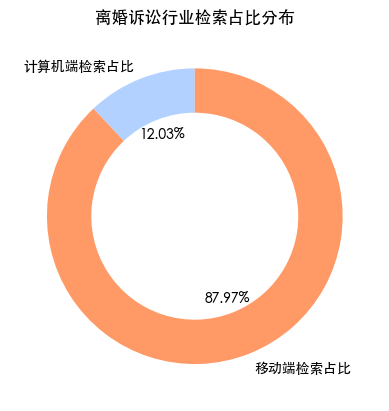

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['计算机端检索占比', '移动端检索占比']
sizes = [12.03, 87.97]
# 颜色，可根据需求调整
colors = ['#b3d1ff', '#ff9966']  

# 创建画布和子图
fig, ax = plt.subplots()
# 绘制甜甜圈图，wedgeprops 用于设置环形宽度
ax.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90, colors=colors,
       wedgeprops={'width': 0.3})  

# 设置标题（可选，根据需求添加）
ax.set_title('离婚诉讼行业检索占比分布')  

plt.show()

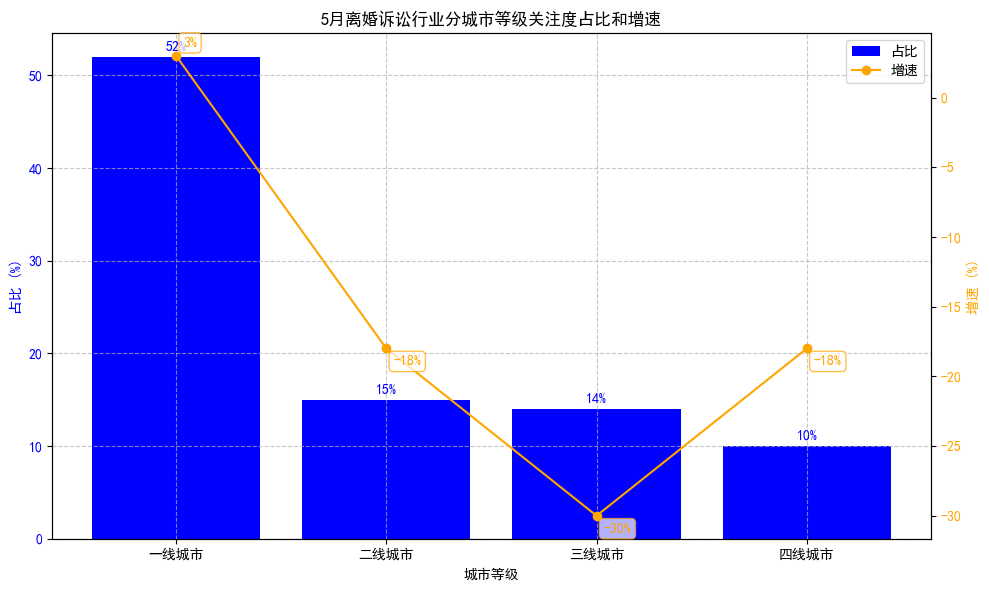

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 城市等级
city_levels = ['一线城市', '二线城市', '三线城市', '四线城市']
# 占比数据（对应柱状图）
proportion = [52, 15, 14, 10]
# 增速数据（对应折线图）
growth_rate = [3, -18, -30, -18]

x = np.arange(len(city_levels))  # 横坐标索引

fig, ax1 = plt.subplots(figsize=(10, 6))  # 调整图表大小

# 绘制柱状图（占比）
bars = ax1.bar(x, proportion, color='blue', label='占比')
ax1.set_ylabel('占比 (%)', color='blue')
ax1.set_xlabel('城市等级')
ax1.set_xticks(x)
ax1.set_xticklabels(city_levels)
ax1.tick_params(axis='y', labelcolor='blue')

# 为柱状图添加数据标注
for bar in bars:
    height = bar.get_height()
    ax1.annotate(f'{height}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center',
                va='bottom',
                color='blue')

# 创建第二个纵轴绘制折线图（增速）
ax2 = ax1.twinx()
line, = ax2.plot(x, growth_rate, color='orange', label='增速', marker='o', markersize=6)
ax2.set_ylabel('增速 (%)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# 为折线图添加数据标注
for i, rate in enumerate(growth_rate):
    ax2.annotate(f'{rate}%',
                xy=(x[i], rate),
                xytext=(5, 5) if rate >= 0 else (5, -5),  # 根据正负调整位置
                textcoords="offset points",
                ha='left',
                va='bottom' if rate >= 0 else 'top',
                color='orange',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="orange", alpha=0.7))

# 添加图例
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

# 设置标题
plt.title('5月离婚诉讼行业分城市等级关注度占比和增速')

# 添加网格线
ax1.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()  # 确保所有元素都适合图表区域
plt.show()    

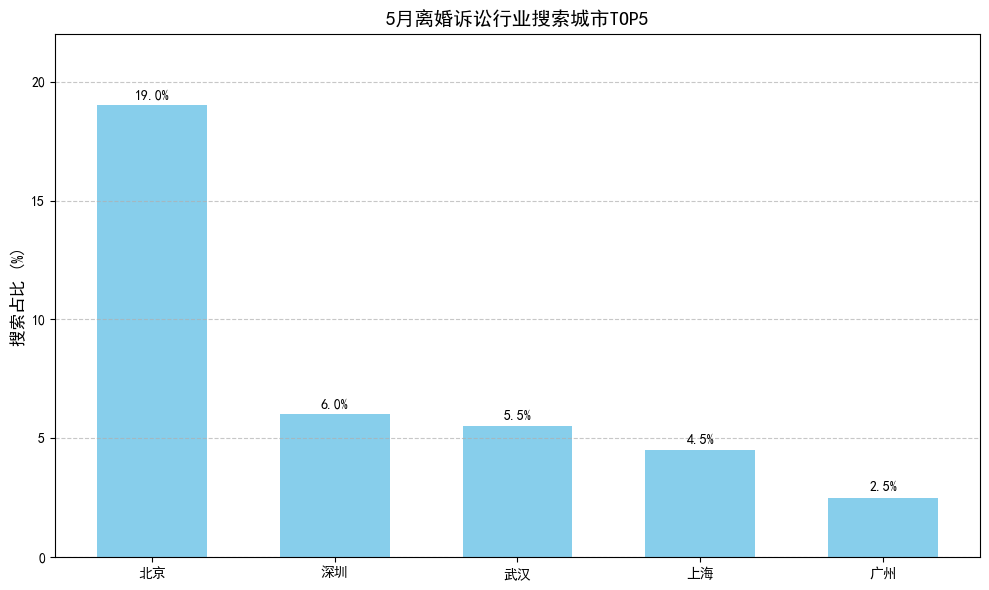

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 城市名称
cities = ['北京', '深圳', '武汉', '上海', '广州']
# 对应搜索占比数据（从图中读取的近似值，可替换为精准数据）
percentages = [19, 6, 5.5, 4.5, 2.5]

x = np.arange(len(cities))  # 用于设置横坐标位置

fig, ax = plt.subplots(figsize=(10, 6))  # 调整图表大小
# 绘制柱状图，调整宽度并设置颜色
bars = ax.bar(x, percentages, width=0.6, color='skyblue')  

# 为每个柱子添加数据标注
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}%',  # 标注文本
                xy=(bar.get_x() + bar.get_width() / 2, height),  # 标注位置
                xytext=(0, 3),  # 垂直偏移量
                textcoords="offset points",
                ha='center',  # 水平对齐方式
                va='bottom',  # 垂直对齐方式
                fontsize=10)  # 字体大小

# 设置横坐标刻度和标签
ax.set_xticks(x)
ax.set_xticklabels(cities, fontsize=10)

# 设置纵坐标范围和刻度
ax.set_ylim(0, 22)  # 略微增加上限，为标注留出空间
ax.set_yticks(np.arange(0, 21, 5))

# 设置坐标轴标题和图表标题
ax.set_ylabel('搜索占比 (%)', fontsize=12)
ax.set_title('5月离婚诉讼行业搜索城市TOP5', fontsize=14)

# 添加网格线，增强可读性
ax.grid(axis='y', linestyle='--', alpha=0.7)

# 美化图表
plt.tight_layout()  # 自动调整布局
plt.show()    

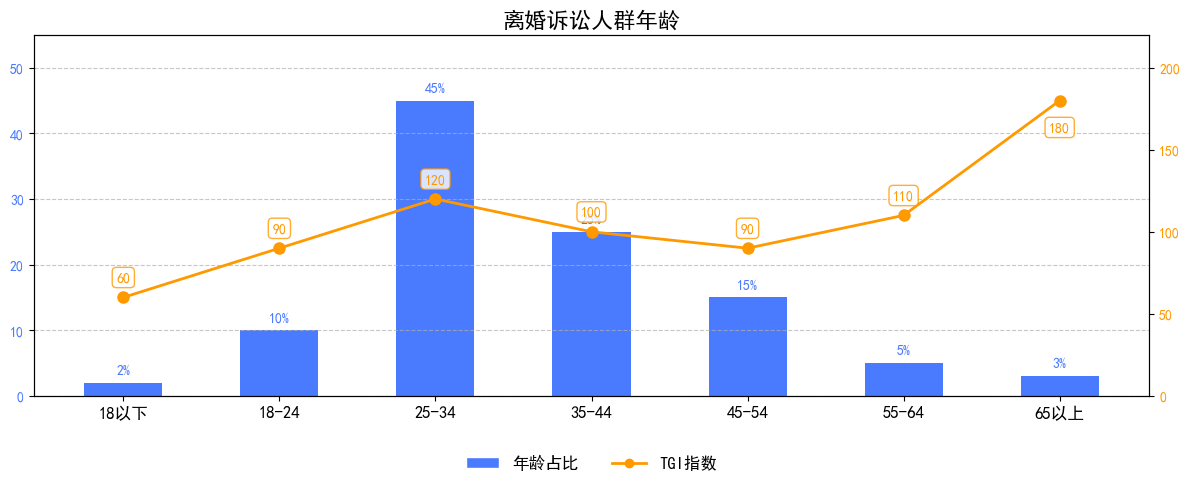

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 数据（根据图表视觉估算，若有精准数据可替换）
categories = ['18以下', '18-24', '25-34', '35-44', '45-54', '55-64', '65以上']
age_percent = [2, 10, 45, 25, 15, 5, 3]  # 年龄占比
tgi_values = [60, 90, 120, 100, 90, 110, 180]  # TGI数据

x = np.arange(len(categories))

# 创建图表
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

# 绘制年龄占比柱状图
bar_plot = ax1.bar(categories, age_percent, color='#4A7AFE', width=0.5, label='年龄')
ax1.set_ylim([0, 55])  # 增加上限以留出标注空间
ax1.tick_params(axis='y', labelcolor='#4A7AFE', labelsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=12)

# 设置左侧坐标轴刻度间隔
ax1.yaxis.set_major_locator(MultipleLocator(10))

# 为柱状图添加数据标注
for i, rect in enumerate(bar_plot):
    height = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2., height + 1,
             f'{age_percent[i]}%',
             ha='center', va='bottom', fontsize=10, color='#4A7AFE')

# 创建第二个y轴绘制TGI折线图
ax2 = ax1.twinx()
line_plot, = ax2.plot(categories, tgi_values, color='#FF9900', marker='o', 
                      label='TGI', linewidth=2, markersize=8)
ax2.set_ylim(0, 220)  # 增加上限以留出标注空间

# 设置右侧坐标轴刻度间隔
ax2.yaxis.set_major_locator(MultipleLocator(50))
ax2.tick_params(axis='y', labelcolor='#FF9900', labelsize=10)

# 为折线图添加数据标注
for i, (x_val, y_val) in enumerate(zip(x, tgi_values)):
    ax2.annotate(f'{y_val}',
                xy=(x_val, y_val),
                xytext=(0, 10) if i != 6 else (0, -15),  # 最后一个点标注在下方
                textcoords="offset points",
                ha='center',
                va='bottom' if i != 6 else 'top',
                fontsize=10,
                color='#FF9900',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#FF9900", alpha=0.8))

# 添加标题
plt.title('离婚诉讼人群年龄', fontsize=16, fontweight='bold')

# 合并图例并调整位置到图表下方
legend_items = [
    Patch(facecolor='#4A7AFE', edgecolor='w', label='年龄占比'),
    Line2D([0], [0], color='#FF9900', marker='o', linestyle='-',
           label='TGI指数', linewidth=2, markersize=6)
]

ax1.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, -0.12),
           ncol=2, fontsize=12, frameon=False)

# 添加网格线增强可读性
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# 优化布局，为图例留出空间
plt.tight_layout(rect=[0, 0.1, 1, 0.95])

# 显示图表
plt.show()    